# Phase 5 — Transfer Learning: Feature Extraction

Goal: an ImageNet-pretrained ResNet50 with the entire backbone frozen, training only
a fresh linear classifier head on top -- the first of three transfer-learning
variants (feature extraction, partial fine-tuning, full fine-tuning) compared
against Phase 4's from-scratch CNN in Phase 8. Uses Phase 2's fixed split and the
exact Phase 3 harness (`src/training/`), unmodified.

Preprocessing needs no changes here: Phase 2's transforms (224x224, ImageNet
mean/std normalization) were deliberately chosen to already match what a
torchvision ImageNet-pretrained backbone expects (`src/data/transforms.py`).

**Status:** Done. Trained on Colab T4 GPU -- test accuracy 97.88%, test macro-F1
97.30%. See the takeaways at the bottom, and `PHASES.md`, for the full writeup and
comparison against Phase 4.

In [1]:
# Colab only: clone (or pull) the GitHub repo and cd into it. Safe to run locally
# too -- the import fails there and this cell is skipped. Repo is public, so a
# plain anonymous HTTPS clone works, no credentials needed.
try:
    import google.colab
    import os
    import shutil

    REPO_URL = "https://github.com/diljithG3/plant-disease-classification.git"
    REPO_DIR = "/content/plant-disease-classification"

    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        # A real repo from an earlier successful clone this session -- update it.
        _git_output = !git -C {REPO_DIR} pull 2>&1
    else:
        # No valid repo here yet -- possibly nothing, possibly a stray leftover
        # directory from an earlier failed attempt this session. Either way, wipe
        # it before cloning fresh: `git clone` refuses to write into a non-empty
        # directory, and re-running this cell after a failed first attempt would
        # otherwise silently take the `pull` branch above against a directory that
        # was never a real git repo, failing with "not a git repository".
        shutil.rmtree(REPO_DIR, ignore_errors=True)
        _git_output = !git clone {REPO_URL} {REPO_DIR} 2>&1

    ok = os.path.isdir(os.path.join(REPO_DIR, ".git"))
    if not ok:
        print("git clone/pull failed:")
        print("\n".join(_git_output))
        raise RuntimeError("git clone/pull failed -- see output above.")

    # os.chdir, not the %cd magic -- %cd does not reliably substitute a Python
    # variable in {}, so it was cd-ing into a literal "{REPO_DIR}" path and
    # silently failing, leaving cwd at /content.
    os.chdir(REPO_DIR)
    print("Repo ready. cwd:", os.getcwd())
except ImportError:
    pass

Repo ready. cwd: /content/plant-disease-classification


In [2]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() is not reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

from src.utils.config import load_config
from src.utils.seed import seed_everything
from src.utils.device import get_device
from src.data import splits, transforms as T, dataset as D
from src.data.fetch_data import fetch_dataset
from src.models.transfer import build_resnet50_feature_extractor
from src.training.trainer import train_model
from src.training.checkpoint import load_checkpoint
from src.training import engine
from src.training.metrics import plot_confusion_matrix

cfg = load_config()
seed_everything(cfg["seed"])
device = get_device(cfg["training"]["device"])
print("Environment:", cfg["env"], "| Device:", device)

fetch_dataset(cfg)  # no-op if already downloaded

Environment: colab | Device: cuda
Cloning https://github.com/spMohanty/PlantVillage-Dataset.git (sparse checkout: raw/color only) ...
Done. 38 class folders at /content/dataset/PlantVillage/color


PosixPath('/content/dataset/PlantVillage/color')

## 1. Load Phase 2's fixed split

Reuses the split and `class_to_idx` cached by `02_data_pipeline.ipynb` unchanged --
same requirement as Phase 4: recomputing a split here would break comparability with
every other phase (`CLAUDE.md`).

In [3]:
DATA_PATH = cfg["data"]["path"]
ARTIFACTS_DIR = cfg["data"]["artifacts_dir"]

splits_path = Path(ARTIFACTS_DIR) / "splits.csv"
class_to_idx_path = Path(ARTIFACTS_DIR) / "class_to_idx.json"

if not splits_path.exists() or not class_to_idx_path.exists():
    raise FileNotFoundError(
        f"{splits_path} or {class_to_idx_path} missing -- run notebooks/02_data_pipeline.ipynb first."
    )

splits_df = pd.read_csv(splits_path)
class_to_idx = splits.build_class_to_idx(DATA_PATH, cache_path=str(class_to_idx_path))
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Loaded split: {len(splits_df)} images, {num_classes} classes")
splits_df["split"].value_counts()

Loaded split: 54305 images, 38 classes


,count
split,
train,38012
test,8147
val,8146


## 2. Dataloaders -- full dataset

Same fixed split, same transforms as every other phase. Meant to run on Colab GPU --
local is CPU-only, fine for the cells above but not for a real training run.

In [4]:
train_transform = T.get_train_transforms(cfg)
eval_transform = T.get_eval_transforms(cfg)

loaders = D.make_dataloaders(
    splits_df,
    class_to_idx,
    train_transform,
    eval_transform,
    batch_size=cfg["dataloader"]["batch_size"],
    num_workers=cfg["dataloader"]["num_workers"],
    data_path=DATA_PATH,
)

for split, loader in loaders.items():
    print(f"{split}: {len(loader.dataset)} images, {len(loader)} batches")

train: 38012 images, 1188 batches
val: 8146 images, 255 batches
test: 8147 images, 255 batches


## 3. Model, loss, optimizer

`build_resnet50_feature_extractor` (`src/models/transfer.py`): torchvision's
ImageNet-pretrained ResNet50 with every backbone parameter frozen
(`requires_grad=False`), and its final `fc` layer replaced with a fresh linear head
for this dataset's 38 classes -- only the head is trained.

Loss is unweighted `CrossEntropyLoss`, matching Phase 4's baseline choice, so any
accuracy/macro-F1 difference from Phase 4 reflects the backbone change, not a
different imbalance-handling strategy. The optimizer is built from
`filter(requires_grad)` over the model's parameters -- i.e. just `fc` -- since
backpropagating through the frozen backbone would be wasted compute.

In [5]:
model = build_resnet50_feature_extractor(num_classes).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} total (backbone frozen, only `fc` trains)")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


Trainable parameters: 77,862 / 23,585,894 total (backbone frozen, only `fc` trains)


## 4. Train

`max_epochs=30` and `early_stopping_patience: 7` on `macro_f1`
(`configs/config.yaml`) -- identical settings to every Phase 4 run, so only the
model differs.

In [6]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase5_resnet50_feature_extraction"
resume_path = checkpoints_dir / "last.pt"
if resume_path.exists():
    print(f"Found checkpoint from an earlier attempt, resuming from {resume_path}")

history = train_model(
    model, loaders, criterion, optimizer, device,
    run_name="phase5_resnet50_feature_extraction", cfg=cfg, class_to_idx=class_to_idx, max_epochs=30,
    resume_from=resume_path if resume_path.exists() else None,
)
pd.DataFrame(history)

train:   0%|          | 0/1188 [00:00<?, ?it/s]

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 0: train_loss=0.6966 val_loss=0.2676 val_acc=0.9449 val_macro_f1=0.9295 (278.8s)


train:   0%|          | 0/1188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beaafa1ca40>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beaafa1ca40>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
    self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()if w.is_alive():

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
          ^if w.is_alive():^^^
^   ^ ^ ^ ^ ^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
 ^     ^   Exception ignored i

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beaafa1ca40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7beaafa1ca40>^
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^^
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
AssertionError:     i

eval:   0%|          | 0/255 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beaafa1ca40>Exception ignored in: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7beaafa1ca40>
if w.is_alive():Traceback (most recent call last):

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
       self._shutdown_workers()
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
     ^if w.is_alive():^
^ ^ ^ ^ ^^^ ^^ ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^^^^^^ ^ 
        File "/usr

Epoch 29: train_loss=0.0461 val_loss=0.0704 val_acc=0.9766 val_macro_f1=0.9692 (271.1s)


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,lr,epoch_time_sec
0,0,0.696634,0.267559,0.944881,0.929535,0.001,278.802052
1,1,0.224976,0.177906,0.959367,0.948745,0.001,283.226400
2,2,0.156790,0.138350,0.963540,0.953997,0.001,276.274257
3,3,0.128913,0.109896,0.971274,0.962808,0.001,283.482959
4,4,0.112365,0.099748,0.971397,0.962746,0.001,272.963361
5,5,0.098231,0.095740,0.970538,0.960339,0.001,278.657340
6,6,0.089902,0.093131,0.972134,0.962615,0.001,292.309092
7,7,0.082361,0.088594,0.972502,0.962624,0.001,279.879905
8,8,0.075803,0.082390,0.975694,0.968260,0.001,280.899156
9,9,0.072636,0.078719,0.975694,0.970364,0.001,290.059682


## 5. Verify checkpoint round-trip, then evaluate on the held-out test set

Same round-trip check as every previous phase: confirm `best.pt` reloads into a
**fresh** model instance and reproduces the metric it was saved with -- then use
that reloaded model for the real held-out test-set evaluation (not the val set used
during training/early stopping, which already influenced checkpoint selection).

In [7]:
checkpoints_dir = Path(cfg["logging"]["checkpoints_dir"]) / "phase5_resnet50_feature_extraction"
best_path = checkpoints_dir / "best.pt"
assert best_path.exists()

fresh_model = build_resnet50_feature_extractor(num_classes).to(device)
payload = load_checkpoint(best_path, fresh_model, optimizer=None, map_location=device)
assert payload["class_to_idx"] == class_to_idx, "class_to_idx did not round-trip!"
print(f"Reloaded checkpoint from epoch {payload['epoch']}, best val {cfg['training']['checkpoint_metric']}={payload['best_metric']:.4f}")

test_metrics = engine.evaluate(fresh_model, loaders["test"], criterion, device, num_classes)
print(f"Test accuracy: {test_metrics['accuracy']:.4f} | Test macro_f1: {test_metrics['macro_f1']:.4f}")

Reloaded checkpoint from epoch 23, best val macro_f1=0.9742


eval:   0%|          | 0/255 [00:00<?, ?it/s]

Test accuracy: 0.9788 | Test macro_f1: 0.9730


## 6. Confusion matrix (test set)

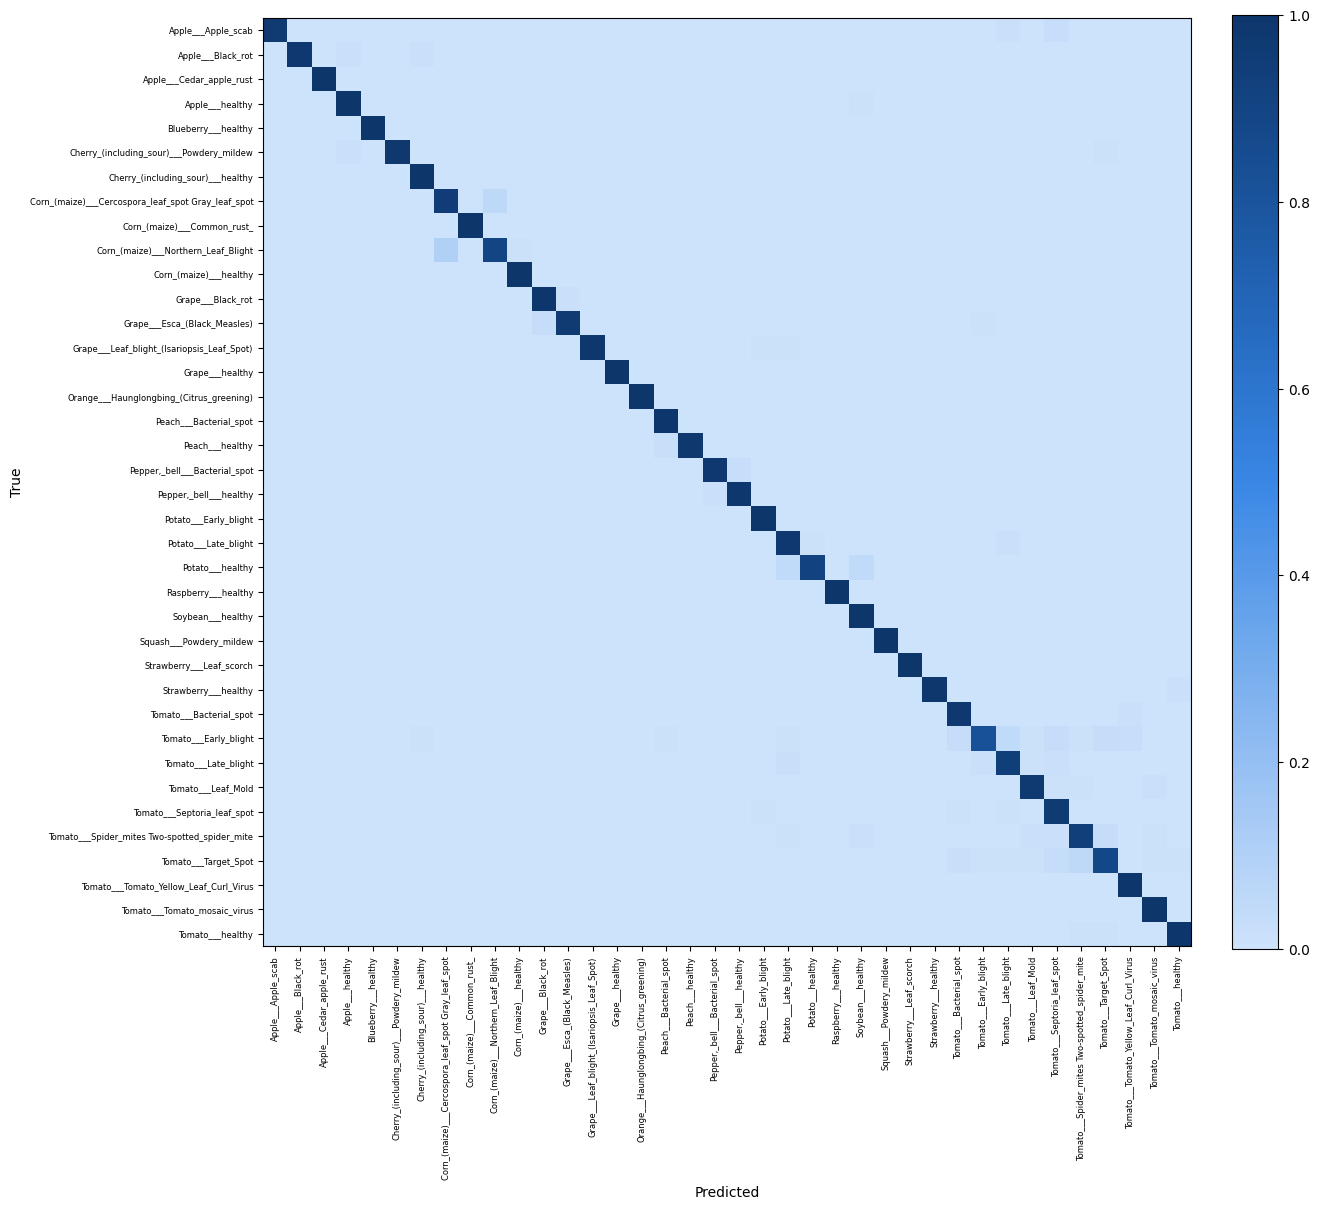

In [8]:
class_names = [idx_to_class[i] for i in range(num_classes)]
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## 7. Per-class recall vs. train-set frequency

Same check Phase 4 ran on its baseline: does the 36x class imbalance show up in
which classes this model struggles with, or does frozen ImageNet feature reuse
sidestep the pattern Phase 4 found (same-species disease confusion, not raw class
frequency)?

In [9]:
recall_series = pd.Series(
    test_metrics["per_class_recall"], index=[idx_to_class[i] for i in range(num_classes)]
).sort_values()

train_counts = splits_df[splits_df["split"] == "train"]["class"].value_counts()
comparison = pd.DataFrame({"train_count": train_counts, "test_recall": recall_series}).sort_values("train_count")

print("Lowest test recall (worst-performing classes):")
print(recall_series.head(10))
comparison

Lowest test recall (worst-performing classes):
Tomato___Early_blight                                 0.820000
Tomato___Target_Spot                                  0.880952
Corn_(maize)___Northern_Leaf_Blight                   0.891156
Potato___healthy                                      0.913043
Tomato___Spider_mites Two-spotted_spider_mite         0.936508
Tomato___Late_blight                                  0.944251
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.948052
Tomato___Septoria_leaf_spot                           0.962264
Grape___Esca_(Black_Measles)                          0.966346
Apple___Apple_scab                                    0.968421
dtype: float64


,train_count,test_recall
Potato___healthy,106,0.913043
Apple___Cedar_apple_rust,192,1.000000
Peach___healthy,252,0.981481
Raspberry___healthy,260,1.000000
Tomato___Tomato_mosaic_virus,261,1.000000
Grape___healthy,296,1.000000
Strawberry___healthy,319,0.985507
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,359,0.948052
Apple___Black_rot,435,0.978495
Apple___Apple_scab,441,0.968421


## Summary & implications for Phase 6

In [10]:
print(f"Feature-extraction test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Feature-extraction test macro_f1: {test_metrics['macro_f1']:.4f}")
print(f"Worst-recall class: {recall_series.index[0]} (recall={recall_series.iloc[0]:.3f}, train_count={int(train_counts.get(recall_series.index[0], 0))})")
print(f"Best-recall class: {recall_series.index[-1]} (recall={recall_series.iloc[-1]:.3f})")

Feature-extraction test accuracy: 0.9788
Feature-extraction test macro_f1: 0.9730
Worst-recall class: Tomato___Early_blight (recall=0.820, train_count=700)
Best-recall class: Tomato___Tomato_mosaic_virus (recall=1.000)


Takeaways:

- **Test accuracy 97.88%, test macro-F1 97.30%** (best val macro-F1 0.9742 at epoch
  23/30 -- early stopping came close but never triggered: only 6 of the required 7
  non-improving epochs elapsed before hitting the `max_epochs=30` ceiling). ~138
  minutes total training time on a T4 GPU -- despite only the 77,862-parameter head
  being trainable, every batch still needs a full forward pass through the
  23.5M-parameter frozen backbone, so this wasn't the fast run the "just training a
  linear head" framing might suggest.
- **Beats Phase 4's unweighted baseline (96.82% / 95.91%) by +1.06pp / +1.39pp, but
  falls short of Phase 4's fully-iterated final result, `SimpleCNNBatchNormDeep`
  (98.97% / 98.46%), by -1.09pp / -1.16pp.** A frozen ImageNet backbone with only a
  linear head beats an *un-iterated* from-scratch CNN, but a from-scratch CNN
  deliberately iterated (batchnorm + depth) on this exact dataset still wins
  outright -- not too surprising given PlantVillage's 38k+ training images give a
  from-scratch model plenty to learn from directly, while frozen generic ImageNet
  features (natural-image categories, not leaf-disease textures) aren't necessarily
  the closest match for this domain. Exactly the kind of comparison Phase 8 exists
  to formalize across all four approaches.
- **`Tomato___Early_blight` is a chronic weak point across every approach so far**,
  not just Phase 4's baseline -- worst-recall class again (0.820, a *mid-range* 700
  train images), landing between Phase 4's baseline (0.767) and its fully-iterated
  result (0.960) on this same class, consistent with the overall ranking above.
- **Imbalance still doesn't cleanly predict difficulty**, reinforcing Phase 4's
  finding with an independent architecture: `Potato___healthy` (the smallest class,
  106 train images) reaches 0.913 recall -- not the worst -- while
  `Tomato___Tomato_mosaic_virus` (only 261 train images) reaches a perfect 1.000.
  Same-species disease confusion, not raw frequency, remains the dominant failure
  mode.
- Next: Phase 6 (partial fine-tuning) -- unfreeze the last N blocks of this same
  ResNet50 backbone, small learning rate, retrain.

## Phase 5 complete

See `PHASES.md` for the full writeup. Next: Phase 6 (partial fine-tuning).